# Convolutional Neural Network (CNN) — Complete Execution

A **Convolutional Neural Network (CNN)** is a deep learning architecture primarily used for processing structured grid data like images. It extracts **hierarchical features** automatically from raw pixels through several layers that progressively detect edges, textures, shapes, and objects.

---

## Overall Architecture Flow

**Input Image → Convolution Layer → Activation → Pooling → (Repeat) → Flatten → Fully Connected Layers → Output**

---

## 1️⃣ Convolution Layer

### Purpose:

To **extract local features** from the input image using small learnable filters (kernels).

### Operation:

Each **filter** slides (convolves) over the input, performing an element-wise multiplication and summation to produce a **feature map**.

### Mathematical form:

\[
Z*{i,j}^{(k)} = \sum*{m=0}^{f-1}\sum*{n=0}^{f-1} X*{i+m, j+n} \cdot W\_{m,n}^{(k)} + b^{(k)}
\]

Where:

- \( X \): input image or feature map
- \( W^{(k)} \): filter (kernel) for feature map \( k \)
- \( b^{(k)} \): bias term
- \( f \): filter size (e.g., 3×3)

### Key Parameters:

- **Filter size (kernel size)** – usually 3×3 or 5×5
- **Stride** – how many pixels the filter moves each time
- **Padding** – adds zero borders to preserve spatial size
- **Number of filters** – determines the depth of the output

### Output:

A set of **feature maps** representing different detected patterns (edges, corners, textures, etc.).

---

## 2️⃣ Activation Function (ReLU)

### Purpose:

To introduce **non-linearity**, allowing the network to learn complex mappings.

### Common choice:

\[
ReLU(x) = \max(0, x)
\]

### Why ReLU:

- Prevents gradient vanishing (compared to sigmoid/tanh)
- Keeps computation efficient

---

## 3️⃣ Pooling Layer

### Purpose:

To **reduce spatial dimensions** (height & width), thus lowering computation and preventing overfitting while retaining key features.

### Types:

- **Max Pooling:** takes the maximum value from each window
- **Average Pooling:** takes the average

### Example:

If window = 2×2 and stride = 2, the image dimensions are halved.

### Effect:

Focuses on the **most prominent features** and provides **translation invariance**.

---

## 4️⃣ Flatten Layer

### Purpose:

Converts the 2D feature maps (from convolution/pooling layers) into a **1D vector**, so it can be fed into **fully connected layers**.

Example:
If the final feature map is of size \( 7 \times 7 \times 64 \),  
then flatten → vector of size \( 7×7×64 = 3136 \).

---

## 5️⃣ Fully Connected (Dense) Layers

### Purpose:

To perform **high-level reasoning** based on the features extracted.

### Operation:

Each neuron receives input from **all** neurons of the previous layer.

\[
y = f(Wx + b)
\]

Where:

- \( W \): weight matrix
- \( x \): flattened input
- \( f \): activation function (ReLU or softmax)

### Often used layers:

- **Dense + ReLU**
- **Dense + Softmax (for classification)**

---

## 6️⃣ Output Layer

### Purpose:

To produce the final prediction (e.g., class probabilities).

### Common activation:

- **Softmax:** for multi-class classification
- **Sigmoid:** for binary classification

Example (Softmax):
\[
P(y_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}
\]

---

## Training Process (Summary)

1. **Forward Pass:** Data flows through the layers → output predicted
2. **Loss Calculation:** Compare prediction vs actual label
3. **Backward Pass (Backpropagation):**  
   Gradients of loss w.r.t. weights are computed (via chain rule)
4. **Weight Update:** Optimizer (like SGD, Adam) adjusts weights using gradients
5. **Repeat:** For all batches and epochs until convergence

---

## Intuitive Understanding

| Layer | Learns   | Example of Feature        |
| ----- | -------- | ------------------------- |
| Conv1 | Edges    | Vertical/Horizontal edges |
| Conv2 | Textures | Patterns, corners         |
| Conv3 | Shapes   | Object parts              |
| Dense | Concepts | Object identity           |

---

## Example Flow (for Image Classification)

**Input (32×32×3)** →  
**Conv (3×3 filters)** → **ReLU** →  
**MaxPool (2×2)** →  
**Conv (3×3)** → **ReLU** → **MaxPool (2×2)** →  
**Flatten** →  
**Dense (128)** → **ReLU** →  
**Dense (10)** → **Softmax (10 classes)**


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import os
import pickle
import mpl_toolkits.mplot3d as plt3d

In [3]:

def check_shapes(tag, *arrays):
    print(f"\n{tag}:")
    for name, arr in arrays:
        print(f"{name}: {arr.shape}")

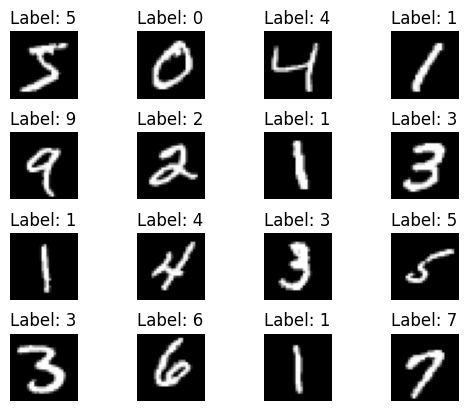

In [4]:
# bring the mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

n_sub_plot = 16

for i in range(n_sub_plot):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
    plt.subplots_adjust(wspace=0.1, hspace=0.5)
plt.show()

In [118]:
# L = 3

# MAX_ITR = 100

# LEARNING_RATE = 0.1

# NO_OF_INPUT = [784, 128, 64, 10]

# NO_OF_OUTPUT = 10

# BATCH_SIZE = 10000

In [5]:
class utils_helper_functions:

    def __init__(self):
        pass

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def loss_fn(self, y_pred, y_true):
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    def eigen(self, output):
        ans = np.eye(10)[output]
        return ans

    def update_parameters(self, weight,bias,grads_w, grads_b , learning_rate=0.1):
        for i in range(len(weight)):
            weight[i] -= learning_rate * grads_w[i]
            bias[i] -= learning_rate * grads_b[i]

In [6]:

import pickle


class FFN:
    def __init__(self, layers: int, layer_input: list, output: int):

        self.Layers = layers

        self.NO_OF_INPUT = layer_input

        self.NO_OF_OUTPUT = output

        self.utils_helper = utils_helper_functions()

        self.load_model()
        
    def forwardpropogation(self, input):
        activation, preactivation = [input], []

        for i in range(self.Layers):

            preactivation.append(np.dot(activation[-1], self.weight[i]) + self.bias[i])

            if i == self.Layers - 1:
                A = self.utils_helper.softmax(preactivation[i])
            else:
                A = self.utils_helper.sigmoid(preactivation[i])

            activation.append(A)

        return activation, preactivation

    def backpropogation(self, activation, preactivation, y):
        m = y.shape[0]
        dz = activation[-1] - y
        grad_w = [None] * self.Layers
        
        grad_b = [None] * self.Layers

        for i in reversed(range(self.Layers)):
            A_prev = activation[i]
        
            grad_w[i] = np.dot(A_prev.T, dz) / m
        
            grad_b[i] = np.sum(dz, axis=0, keepdims=True) / m

            dA_prev = np.dot(dz, self.weight[i].T)
        
            if i > 0:
                sigmoid_Z = 1 / (1 + np.exp(-preactivation[i - 1]))
        
                dz = dA_prev * (sigmoid_Z * (1 - sigmoid_Z))
            else:
                dZ=dA_prev
        
        return grad_w, grad_b ,dZ

    
    def save_model(self):
        os.makedirs("./saves", exist_ok=True)
        with open(f"./saves/fnn_sub_model.pkl", "wb") as f:
            pickle.dump({"weights": self.weight, "biases": self.bias}, f)

    def load_model(self):
        try:
            with open(f"./saves/fnn_sub_model.pkl", "rb") as f:
                data = pickle.load(f)
                self.weight = data["weights"]
                self.bias = data["biases"]
        except FileNotFoundError as e:
            print("Error loading model:", e)
            
            self.weight, self.bias = self.initialize_parameters(method="xavier")
            
            print("Initialized new parameters.")

    def initialize_parameters(self,method="xavier"):

        weights = []
        biases = []

        for i in range(len(self.NO_OF_INPUT) - 1):
            n_in = self.NO_OF_INPUT[i]
            n_out = self.NO_OF_INPUT[i+1]

            if method == "xavier":
                W = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)
            elif method == "he":
                W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            else:
                raise ValueError("Invalid method. Use 'xavier' or 'he'.")

            b = np.zeros((1, n_out))

            weights.append(W)
            biases.append(b)

        return weights, biases


In [7]:
class Convolution_Layer:
    def __init__(self, layer_no, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.layer_no = layer_no
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        
        self.load_layer()


    def __im2col(self, X):
        B,C,H,W = X.shape
        k = self.kernel_size
        s = self.stride
        out_h = int(np.floor((H + 2*self.padding - k)/s) + 1)
        out_w = int(np.floor((W + 2*self.padding - k)/s) + 1)
        X_padded = np.pad(X, ((0,0),(0,0),(self.padding,self.padding),(self.padding,self.padding)))
        
        i0 = np.repeat(np.arange(k), k)
        i0 = np.tile(i0, C)
        i1 = s * np.repeat(np.arange(out_h), out_w)
        j0 = np.tile(np.arange(k), k*C)
        j1 = s * np.tile(np.arange(out_w), out_h)
        i = i0.reshape(-1,1) + i1.reshape(1,-1)
        j = j0.reshape(-1,1) + j1.reshape(1,-1)
        k_idx = np.repeat(np.arange(C), k*k).reshape(-1,1)
        
        cols = X_padded[:, k_idx, i, j]
        cols = cols.transpose(1,2,0).reshape(C*k*k, -1)
        return cols, out_h, out_w, X_padded
    
    def forward(self, X):
        self.X_shape = X.shape
        self.cols, self.out_h, self.out_w, self.X_padded = self.__im2col(X)
        W_col = self.W.reshape(self.out_channels, -1)
        out = W_col @ self.cols + self.b
        out = out.reshape(self.out_channels, self.out_h, self.out_w, X.shape[0])
        out = out.transpose(3,0,1,2)
        return out
    
    def col2im(self,cols, X_shape, kernel_size, stride, padding):
        B, C, H, W = X_shape
        k = kernel_size
        s = stride
        H_padded, W_padded = H + 2*padding, W + 2*padding

        X_padded = np.zeros((B, C, H_padded, W_padded))

        out_h = (H_padded - k)//s + 1
        out_w = (W_padded - k)//s + 1

        cols_reshaped = cols.reshape(B, C, k, k, out_h, out_w)
        for i in range(k):
            for j in range(k):
                X_padded[:, :, i:i+out_h*s:s, j:j+out_w*s:s] += cols_reshaped[:, :, i, j, :, :]

        if padding > 0:
            return X_padded[:, :, padding:-padding, padding:-padding]
        else:
            return X_padded

    def backward(self, dOut):
        B, C, H, W = self.X_shape
        k = self.kernel_size
        s = self.stride

        dOut_flat = dOut.transpose(1,2,3,0).reshape(self.out_channels, -1)

        dW = dOut_flat @ self.cols.T
        dW = dW.reshape(self.W.shape)

        dB = np.sum(dOut_flat, axis=1, keepdims=True)

        W_col = self.W.reshape(self.out_channels, -1)
        dCols = W_col.T @ dOut_flat

        dCols = dCols.reshape(C*k*k, self.out_h*self.out_w, B).transpose(2,0,1)

        dX = self.col2im(dCols, self.X_shape, k, s, self.padding)

        self.dW = dW
        self.db = dB

        return dX


    def save_layer(self):
        os.makedirs("./saves", exist_ok=True)
        with open(f"./saves/cnn_layer_{self.layer_no}.pkl", "wb") as f:
            pickle.dump({"weights": self.W, "biases": self.b}, f)

    def load_layer(self):
        try:
            with open(f"./saves/cnn_layer_{self.layer_no}.pkl", "rb") as f:
                data = pickle.load(f)
                self.W = data["weights"]
                self.b = data["biases"]
        except FileNotFoundError as e:
            print("Error loading model:", e)
            
            limit = np.sqrt(2.0 / (self.in_channels * self.kernel_size * self.kernel_size))
            self.W = np.random.randn(self.out_channels, self.in_channels, self.kernel_size, self.kernel_size) * limit
            self.b = np.zeros((self.out_channels, 1))
            
            print("Initialized new parameters.")

def im2col(X, pool_size, stride):
    B, C, H, W = X.shape
    p = pool_size
    s = stride
    out_h = (H - p) // s + 1
    out_w = (W - p) // s + 1
    
    cols = np.zeros((B, C, p, p, out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            cols[:, :, :, :, i, j] = X[:, :, i*s:i*s+p, j*s:j*s+p]
    
    cols = cols.reshape(B, C, p*p, out_h*out_w)
    return cols, out_h, out_w


def col2im(cols, X_shape, pool_size, stride):
    B, C, H, W = X_shape
    p = pool_size
    s = stride
    out_h = (H - p) // s + 1
    out_w = (W - p) // s + 1
    X = np.zeros((B, C, H, W))
    
    cols = cols.reshape(B, C, p, p, out_h, out_w)
    for i in range(out_h):
        for j in range(out_w):
            X[:, :, i*s:i*s+p, j*s:j*s+p] += cols[:, :, :, :, i, j]
    return X


class Pooling_Layer:
    def __init__(self,layer_no, pool_size=2, stride=2, mode="max"):
        self.pool_size = pool_size
        self.stride = stride
        self.mode = mode
        self.layer_no = layer_no
        
    def forward(self, X):
        self.X_shape = X.shape
        p, s = self.pool_size, self.stride
        
        cols, out_h, out_w = im2col(X, p, s)
        B, C, _, N = cols.shape
        
        if self.mode == "max":
            max_idx = np.argmax(cols, axis=2)
            out = cols[np.arange(B)[:,None,None],
                       np.arange(C)[None,:,None],
                       max_idx,
                       np.arange(N)[None,None,:]]
        else:
            out = np.mean(cols, axis=2)
            max_idx = None
        
        out = out.reshape(B, C, out_h, out_w)
        self.cache = (cols, max_idx)
        return out

    def backward(self, dOut):
        cols, max_idx = self.cache
        B, C, K2, N = cols.shape
        p = self.pool_size
        
        dCols = np.zeros_like(cols)
        dOut_flat = dOut.reshape(B, C, N)
        
        if self.mode == "max":
            np.put_along_axis(dCols, max_idx[:, :, None, :], dOut_flat[:, :, None, :], axis=2)
        else:
            dCols += dOut_flat[:, :, None, :] / K2
        
        dX = col2im(dCols, self.X_shape, p, self.stride)
        return dX


In [ ]:
from typing import List, Union


class LeNet5:
    def __init__(self, layers: List[Union[Convolution_Layer, Pooling_Layer]], ffn: FFN):
        self.layers = layers
        self.ffn = ffn
        self.utils_helper = utils_helper_functions()

    def __forward_pass(self, X):
        """
        Forward pass through all conv/pool layers.
        Returns the last feature map (to flatten for FFN)
        """
        out = X
        self.cache = []
        for layer in self.layers:
            out = layer.forward(out)
            self.cache.append(out)

        return out

    def __backward_pass(self, dFFN):
        """
        Backward pass through conv/pool layers.
        dFFN: gradient from FFN w.r.t input
        """
        dOut = dFFN
        for layer in reversed(self.layers):
            dOut = layer.backward(dOut)

    def train(self, x_train, y_train, MAX_ITR, learning_rate: float = 0.1, BATCH_SIZE: int = 100):
        idx = np.arange(len(x_train))
        np.random.shuffle(idx)
        x_train = x_train[idx]
        y_train = y_train[idx]
        print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
        losses = []
        
        for epoch in range(MAX_ITR):
            
            for i in range(len(x_train) // BATCH_SIZE):
                x_batch = x_train[i*BATCH_SIZE:(i+1)*BATCH_SIZE].reshape(BATCH_SIZE, 1, 28, 28) / 255.0
                y_batch = self.utils_helper.eigen(y_train[i*BATCH_SIZE:(i+1)*BATCH_SIZE])
                
                
                conv_out = self.__forward_pass(x_batch)
                ffn_input = conv_out.reshape(conv_out.shape[0], -1)
                
                activation, preactivation = self.ffn.forwardpropogation(ffn_input)

                loss = self.utils_helper.loss_fn(activation[-1], y_batch)
                losses.append(loss)

                dW, db, dFFN_input = self.ffn.backpropogation(activation, preactivation, y_batch)
                self.ffn.utils_helper.update_parameters(self.ffn.weight, self.ffn.bias, dW, db, learning_rate)

                dFFN_input = dFFN_input.reshape(conv_out.shape)
                self.__backward_pass(dFFN_input)
                
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.show()
        return losses

    def test(self, x_test, y_test):
        x_test = x_test.reshape(x_test.shape[0], 1, 28, 28) / 255.0
        conv_out = self.__forward_pass(x_test)
        ffn_input = conv_out.reshape(conv_out.shape[0], -1)
        activation, _ = self.ffn.forwardpropogation(ffn_input)
        y_pred = np.argmax(activation[-1], axis=1)
        accuracy = np.mean(y_pred == y_test) * 100
        
        print(f"Test Accuracy: {accuracy:.2f}%")
        return accuracy

    def save_model(self):
        for layer in self.layers:
            if hasattr(layer, "save_layer"):
                layer.save_layer()
        self.ffn.save_model()
    

    def load_model(self):
        for layer in self.layers:
            if hasattr(layer, "load_layer"):
                layer.load_layer()
        self.ffn.load_model()

    def plot_test(self, x_test, y_test):
        n_sub_plot = 16
        conv_out = self.__forward_pass(x_test)
        print(conv_out.shape)
        ffn_input = conv_out.reshape(conv_out.shape[0], -1)    
        activation, _ = self.ffn.forwardpropogation(ffn_input)
        for i in range(n_sub_plot):
            plt.subplot(4, 4, i + 1)
            plt.imshow(x_test[i].squeeze(), cmap="gray")
            plt.title(f"Label: {y_test[i]} \n Output: {np.argmax(activation[-1][i])}")
            plt.axis("off")
            plt.subplots_adjust(wspace=1.0, hspace=1.0)

x_train shape: (1000, 28, 28), y_train shape: (1000,)
Epoch 0, Loss: 1.8155
Epoch 1, Loss: 1.7522
Epoch 2, Loss: 1.6908
Epoch 3, Loss: 1.6296
Epoch 4, Loss: 1.5690
Epoch 5, Loss: 1.5095
Epoch 6, Loss: 1.4516
Epoch 7, Loss: 1.3956
Epoch 8, Loss: 1.3419
Epoch 9, Loss: 1.2905
Epoch 10, Loss: 1.2417
Epoch 11, Loss: 1.1954
Epoch 12, Loss: 1.1514
Epoch 13, Loss: 1.1097
Epoch 14, Loss: 1.0701
Epoch 15, Loss: 1.0326
Epoch 16, Loss: 0.9969
Epoch 17, Loss: 0.9630
Epoch 18, Loss: 0.9308
Epoch 19, Loss: 0.9002
Epoch 20, Loss: 0.8711
Epoch 21, Loss: 0.8434
Epoch 22, Loss: 0.8172
Epoch 23, Loss: 0.7923
Epoch 24, Loss: 0.7688
Epoch 25, Loss: 0.7465
Epoch 26, Loss: 0.7253
Epoch 27, Loss: 0.7053
Epoch 28, Loss: 0.6863
Epoch 29, Loss: 0.6683
Epoch 30, Loss: 0.6513
Epoch 31, Loss: 0.6351
Epoch 32, Loss: 0.6197
Epoch 33, Loss: 0.6050
Epoch 34, Loss: 0.5911
Epoch 35, Loss: 0.5778
Epoch 36, Loss: 0.5651
Epoch 37, Loss: 0.5529
Epoch 38, Loss: 0.5413
Epoch 39, Loss: 0.5302
Epoch 40, Loss: 0.5195
Epoch 41, Los

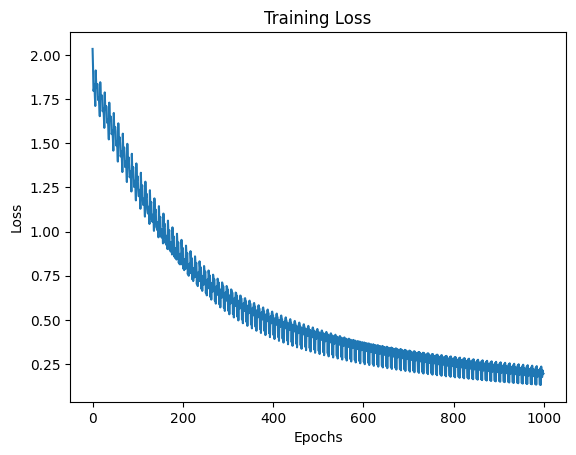

Test Accuracy: 88.07%
(16, 16, 4, 4)


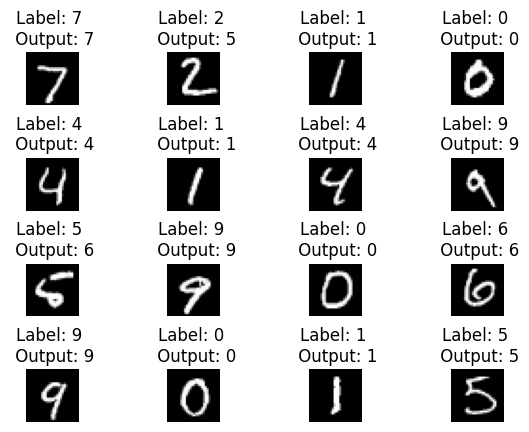

In [24]:
layers = [
    Convolution_Layer(layer_no=1, in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0),
    Pooling_Layer(layer_no=2, pool_size=2, stride=2, mode="max"),
    Convolution_Layer(layer_no=3, in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
    Pooling_Layer(layer_no=4, pool_size=2, stride=2, mode="max")
]

model = LeNet5(layers, FFN(3, [256,120, 84, 10], 10))


losses = model.train(x_train[:1000], y_train[:1000], MAX_ITR=100, learning_rate=0.15, BATCH_SIZE=100)

# Save
model.save_model()
# Test
accuracy = model.test(x_test, y_test)


model.plot_test(x_test[:16].reshape(x_test[:16].shape[0], 1, 28, 28) / 255.0, y_test[:16])

![alt text](<Screenshot 2025-10-15 234935-1.png>)

(16, 16, 4, 4)


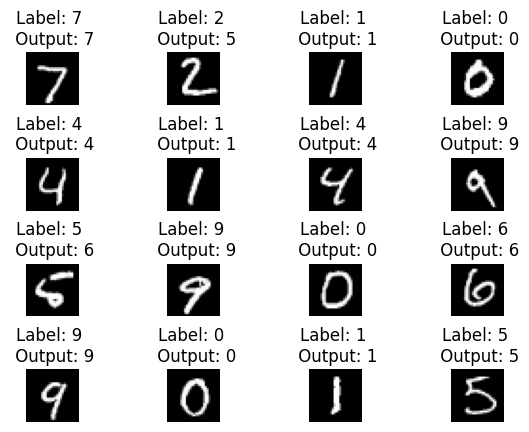

In [26]:
# x_test.shape

model.plot_test(x_test[:16].reshape(x_test[:16].shape[0], 1, 28, 28) / 255.0, y_test[:16])

model.save_model()

In [2]:

import numpy as np

def __im2col(self, X):
        B,C,H,W = X.shape
        
        print(f"dim of the B,C,H,W = {B,C,H,W} \n")
        k = 2
        s = 1
        out_h = int(np.floor((H  - k)/s) + 1)
        out_w = int(np.floor((W  - k)/s) + 1)
        
        print(f"out_h is:{out_h} ,out_w is:{out_w} \n")
        X_padded = X
        
        i0 = np.repeat(np.arange(k), k)
        print(f"i0 is : with shape of {i0.shape} \n")
        i0 = np.tile(i0, C)
        i1 = s * np.repeat(np.arange(out_h), out_w)
        print(f"i1 is : with shape of {i1.shape} \n")
        j0 = np.tile(np.arange(k), k*C)
        print(f"j0 is : with shape of {j0.shape} \n")
        j1 = s * np.tile(np.arange(out_w), out_h)
        print(f"j1 is : with shape of {j1.shape} \n")

        i = i0.reshape(-1,1) + i1.reshape(1,-1)
        j = j0.reshape(-1,1) + j1.reshape(1,-1)

        print(f"i is : with shape of {i.shape} \n")
        print(f"j is : with shape of {j.shape} \n")

        k_idx = np.repeat(np.arange(C), k*k).reshape(-1,1)
        print(f"k_idx is : with shape of {k_idx.shape} \n")
        cols = X_padded[:, k_idx, i, j]
        print(f"cols is : with shape of {cols.shape} \n")
        
        cols = cols.transpose(1,2,0).reshape(C*k*k, -1)
        
        print(f"cols is : with shape of {cols.shape} \n")
        return cols, out_h, out_w, X_padded


cols,_,_,_ = __im2col(None, np.random.randn(1,3,5,5))

dim of the B,C,H,W = (1, 3, 5, 5) 

out_h is:4 ,out_w is:4 

i0 is : with shape of (4,) 

i1 is : with shape of (16,) 

j0 is : with shape of (12,) 

j1 is : with shape of (16,) 

i is : with shape of (12, 16) 

j is : with shape of (12, 16) 

k_idx is : with shape of (12, 1) 

cols is : with shape of (1, 12, 16) 

cols is : with shape of (12, 16) 



In [ ]:
model.load_model()


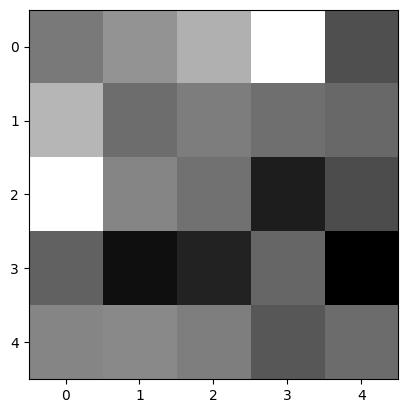

In [69]:

W_conv_1=model.layers[0].W
# W_conv_1=W_conv_1.transpose(0,2,3,1).squeeze()
# print(W_conv_1.shape,W_conv_1[1,:,:].shape)
# mat=np.zeros((28,28))

# for i in range(mat.shape[1]-5+1):
#     for j in range(mat.shape[0]-5+1):
#         mat[i:i+5,j:j+5]+=W_conv_1[1,:,:]
        
# mat = mat / np.dot(mat.reshape(-1),mat.reshape(-1).T)


# plt.imshow(mat, cmap="gray")
# plt.show()

w = W_conv_1[1,:,:].squeeze()
x_star = w / np.linalg.norm(w)
plt.imshow(x_star, cmap='gray')

# for i in range(W_conv_1.shape[0]):
#     x = W_conv_1 / np.dot(W_conv_1[i].reshape(-1),W_conv_1[i].reshape(-1).T)

#     plt.subplot(2, 3, i + 1)
#     plt.imshow(x[i], cmap="gray")
#     plt.title(f"Filter: {i}")
#     plt.axis("off")
#     plt.subplots_adjust(wspace=0.1, hspace=0.5)